# **HANDS ON: INTRODUCCIÓN A ESTADÍSTICA DESCRIPTIVA**


Una vez visto la presentación ***Introducción a la estadística descriptiva***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

De igual manera, se proporciona la **solución** de este notebook a través del siguiente [enlace](https://colab.research.google.com/drive/1Nt9D-SMIfCHgGkgwH6SYyUa26J5bJ1XV?usp=sharing).


## **ANÁLISIS UNIVARIABLE**

El **análisis univariable** es el análisis que se realiza a **una sola variable** a la vez. Su propósito principal es **describir la distribución, frecuencia y tendencia** de esa única característica, sin considerar relaciones de causa o efecto.

***NOTA:*** *Se hará el uso de las bibliotecas de **Pandas** y **Seaborn** para usar datasets precargados sin entrar a tanto detalle a las librerías mismas. Para ello, se explicará mas a detalle en el siguiente módulo.*

In [1]:
#Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importar dataset
df_tips = sns.load_dataset('tips')
df_tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
# Mostrar propiedades de la tabla
df_tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
# Mostrar resumen estadístico
df_tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
# Realizar una proporción de probabilidad
media =  round(df_tips['total_bill'].mean(), 2)
std = round(df_tips['total_bill'].std(), 2)
prop_prob = round((std/media)*100, 2)
print(f'Los datos se separan en promedio un {prop_prob}% de la media.')

Los datos se separan en promedio un 44.97% de la media.


#### **MEDIDAS DE TENDENCIA CENTRAL**

Las **medidas de tendencia central** (MTC) son métricas estadísticas que nos permiten **resumir un conjunto de datos en un solo valor**. Estas métricas nos indican cuál es el **valor que se encuentra en el centro** de un conjunto de datos.

Las medidas de tendencia central son:

*   **Media:** Es el valor promedio de un conjunto de datos y es muy sensible a los sesgos.

*   **Mediana:** Es el valor que se encuentra en el centro de un conjunto de datos ordenados y es menos sensible a los sesgos.

*   **Moda:** Es el valor que aparece con más frecuencia en un conjunto de datos.

In [6]:
# Definir variables
media =  round(df_tips['total_bill'].mean(), 2)
mediana = round(df_tips['total_bill'].median(), 2)
moda = round(df_tips['total_bill'].mode()[0], 2)
print(f'Las medidas de tendencia central son: media = {media}, mediana = {mediana} y moda = {moda}.')

Las medidas de tendencia central son: media = 19.79, mediana = 17.8 y moda = 13.42.


In [7]:
# Definir listas
mtc = [media, mediana, moda]
nombres = ['Media', 'Mediana', 'Moda']
mtc_colors = ['blue', 'orange', 'green']
mtc_configuraciones = zip(mtc, nombres, mtc_colors)


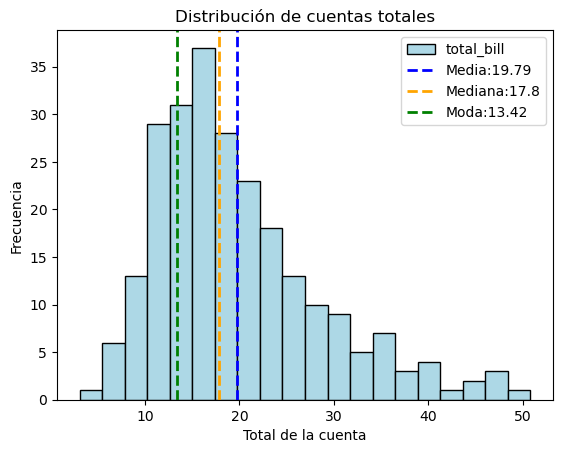

In [8]:
# Visualizar métricas de tendencia central
from matplotlib.lines import lineStyles
df_tips['total_bill'].plot(kind='hist', bins=20, color='lightblue', edgecolor='black')
plt.title('Distribución de cuentas totales')
plt.xlabel('Total de la cuenta')
plt.ylabel('Frecuencia')

for dato, nombre, color in mtc_configuraciones:
    plt.axvline(x = dato, c = color, linestyle='--', linewidth=2, label=f'{nombre}:{dato}')
plt.legend()
plt.show()

### **MEDIDAS DE DISPERSIÓN**

Las **medidas de dispersión** indican qué tan **extendidos o separados se encuentran los datos de una distribución** respecto a un valor central. Son fundamentales para determinar la **variabilidad y la confiabilidad** de un conjunto de datos.

Las métricas de disperción mas utilizadas son:

*   **Desviación estandar:** Es la media de las desviaciones de los datos, a mayor desviación los datos estarán más dispersos.

*   **Cuartíl:** Son los valores estadísticos que dividen una distribución en 4 partes iguales formando un **rango intercuartílico**.

#### **DESVIACIÓN ESTANDAR**

La **desviación estándar** es una medida de la dispersión de un conjunto de datos numéricos. Se calcula como la media de las desviaciones de los datos con respecto a la media.

Se interpreta como **la distancia promedio entre los datos y la media.** Una **desviación estándar baja** indica que los datos están agrupados cerca de la media, mientras que una **desviación estándar alta** indica que los datos están más dispersos.

In [10]:
# Definir variables
x = range(len(df_tips['total_bill']))
y = df_tips['total_bill']
std = np.std(df_tips['total_bill'])

In [11]:
# Definir listas
std_datos = [media ,  media + std, media - std]
std_nombres = ['Media', 'Desviación estandar', None]
std_colores = ['blue', 'red', 'red']
std_configuraciones = zip(std_datos, std_nombres, std_colores)

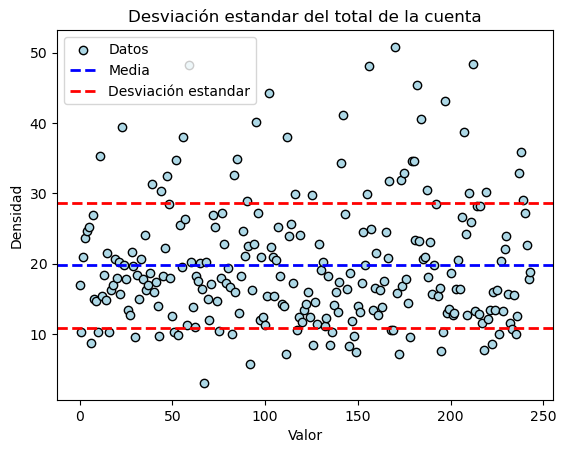

In [13]:
# Visualizar dipersión de los datos
plt.scatter(x, y, color='lightblue', edgecolor='black', label='Datos')
plt.title('Desviación estandar del total de la cuenta')
plt.xlabel('Valor')
plt.ylabel('Densidad')

for dato, nombre, color in std_configuraciones:
    plt.axhline(y = dato, c = color, label = nombre, linestyle='--', linewidth=2)
plt.legend()
plt.show()

#### **PERCENTILES**

Los **percentiles** son valores estadísticos que dividen una distribución de datos en **100 partes iguales** (por el cual puede ser asociado como porcentaje). Se utilizan comúnmente en estadísticas y análisis de datos para entender la posición de un valor específico en relación con otros valores en un conjunto de datos.

Los percentiles pueden ser trabajados por **cuartiles**, el cual es dividir en **4 partes iguales** la misma distribución, siendo cada parte una agrupación del 25% de elementos de la distribución. Su gráfico mas representativo es el **gráfico de caja** y forma un **rango intercuartílico** (IQR) cuando se realiza la diferencia entre el primer y tercer cuartil.

In [14]:
# Definir variables
percentil = np. percentile(df_tips['total_bill'],[25, 50, 75])

q_1 = round(percentil[0], 2)
q_2 = round(percentil[1], 2)
q_3 = round(percentil[2], 2)
iqr = round(q_3 - q_1, 2)

C:\Users\canek\AppData\Local\Temp\ipykernel_20024\1146053467.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


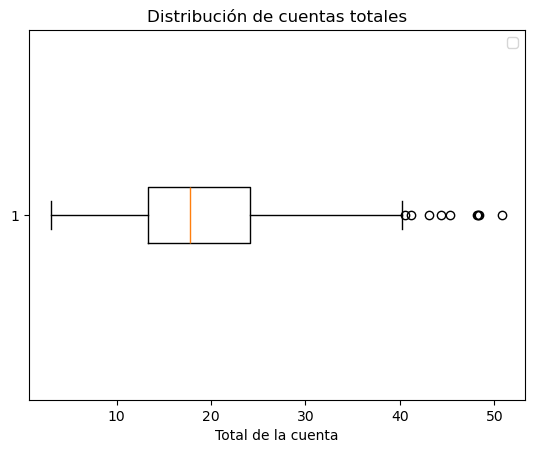

In [18]:
# Visualizar percentiles
plt.boxplot(df_tips['total_bill'], vert=False)
plt.title('Distribución de cuentas totales')
plt.xlabel('Total de la cuenta')
plt.legend()
plt.show()

Text(0, 0.5, 'Densidad')

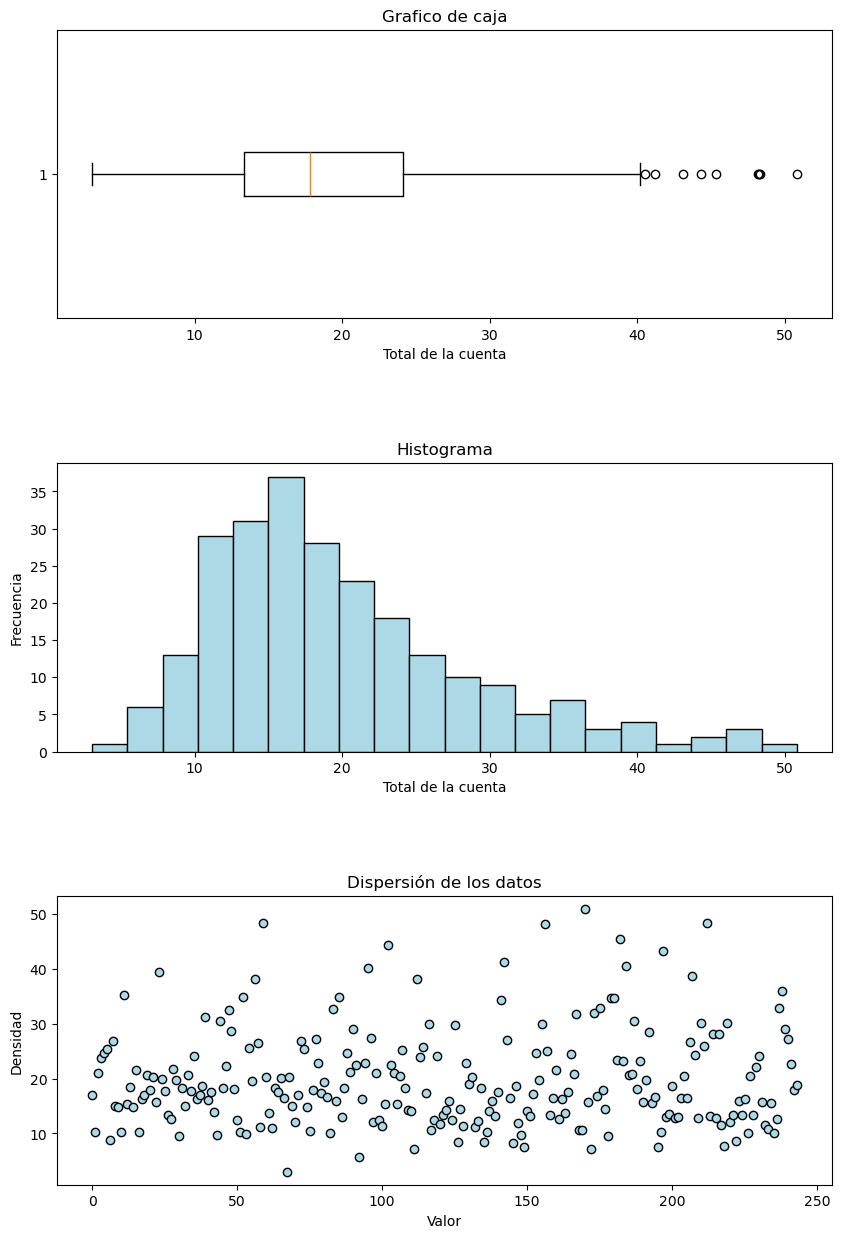

In [19]:
# Asociar gráficos
fig, ax = plt.subplots(3,figsize=(10, 15),gridspec_kw = {'hspace':0.5})
ax[0].boxplot(df_tips['total_bill'], vert=False)
ax[0].set_title('Grafico de caja')
ax[0].set_xlabel('Total de la cuenta')
ax[1].hist(df_tips['total_bill'], bins=20, color='lightblue', edgecolor='black')
ax[1].set_title('Histograma')
ax[1].set_xlabel('Total de la cuenta')
ax[1].set_ylabel('Frecuencia')
ax[2].scatter(x, y, color='lightblue', edgecolor='black', label='Datos')
ax[2].set_title('Dispersión de los datos')
ax[2].set_xlabel('Valor')
ax[2].set_ylabel('Densidad')


## **ANÁLISIS BIVARIABLE**

El **análisis bivariable** consiste en el estudio de la **relación entre dos variables** simultáneamente. Se utiliza para **determinar si existe una asociación, correlación o dependencia** entre ellas.

### **CORRELACIÓN**

La **correlación** es una medida estadística que **cuantifica la fuerza y la dirección de la relación** o asociación **entre dos o más variables**, describiendo de esa manera cómo el **cambio en una variable se asocia con el cambio en otra**.

**La correlación no implica causalidad**. Que dos variables cambien juntas **no significa necesariamente que una sea la causa de la otra**; ambos cambios podrían deberse a un tercer factor desconocido.

#### **MULTIVARIABLE**

Analiza la **interacción y los patrones entre tres o más variables** simultáneamente. Busca entender cómo múltiples factores influyen en un resultado o se agrupan entre sí.

Las **matrices de correlación** muestran los **coeficientes de correlación bivariados** para todos los pares posibles en un conjunto de datos grande.

In [20]:
# Definir variables
columnas = ['total_bill', 'tip', 'size']
corr = df_tips[columnas].corr()
long_col = len(columnas)

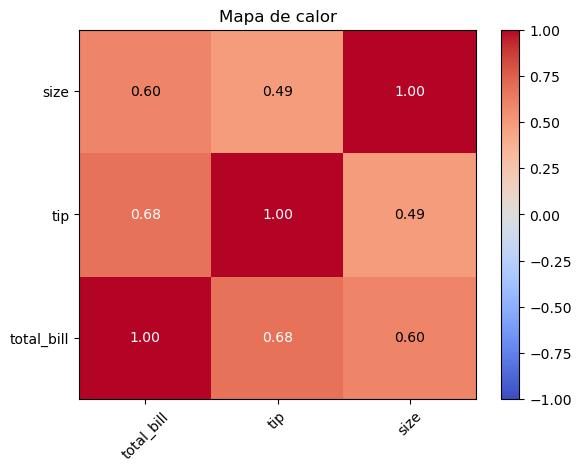

In [21]:
# Visualizar mapa de calor
heatmap = plt.pcolor(corr, cmap = 'coolwarm', vmin = -1, vmax = 1) # vmin y vmax para establecer el rango de colores
plt.title('Mapa de calor')
plt.xticks(np.arange(0.5, long_col, 1), columnas, rotation=45)
plt.yticks(np.arange(0.5, long_col), columnas)

for i in range(long_col):
    for j in range(long_col):
        plt.text(j + 0.5, i + 0.5, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='white' if abs(corr.iloc[i,j]) > 0.6 else 'black')
plt.colorbar(heatmap)
plt.show()



#### **BIVARIABLE**

Examina la **relación entre dos variables aleatorias**. Su objetivo es determinar si existe una **asociación, dirección (positiva o negativa) y fuerza**. Algunas herramientas comunes son:

*   **Coeficiente de Pearson:** Mide la fuerza de una relación lineal entre variables cuantitativas.

*   **Diagramas de dispersión:** Gráficos de "nube de puntos" que permiten visualizar la tendencia entre las dos variables.

In [24]:
# Definir variables
corr_cuenta_propina = round(df_tips['total_bill'].corr(df_tips['tip']), 2)
corr_mesa_cuenta = round(df_tips['size'].corr(df_tips['total_bill']), 2)
corr_mesa_propina = round(df_tips['size'].corr(df_tips['tip']), 2)
print(f'La correlación entre el total de la cuenta y la propina es: {corr_cuenta_propina}.')
print(f'La correlación entre el tamaño de la mesa y el total de la cuenta es: {corr_mesa_cuenta}.')
print(f'La correlación entre el tamaño de la mesa y la propina es: {corr_mesa_propina}.')

La correlación entre el total de la cuenta y la propina es: 0.68.
La correlación entre el tamaño de la mesa y el total de la cuenta es: 0.6.
La correlación entre el tamaño de la mesa y la propina es: 0.49.


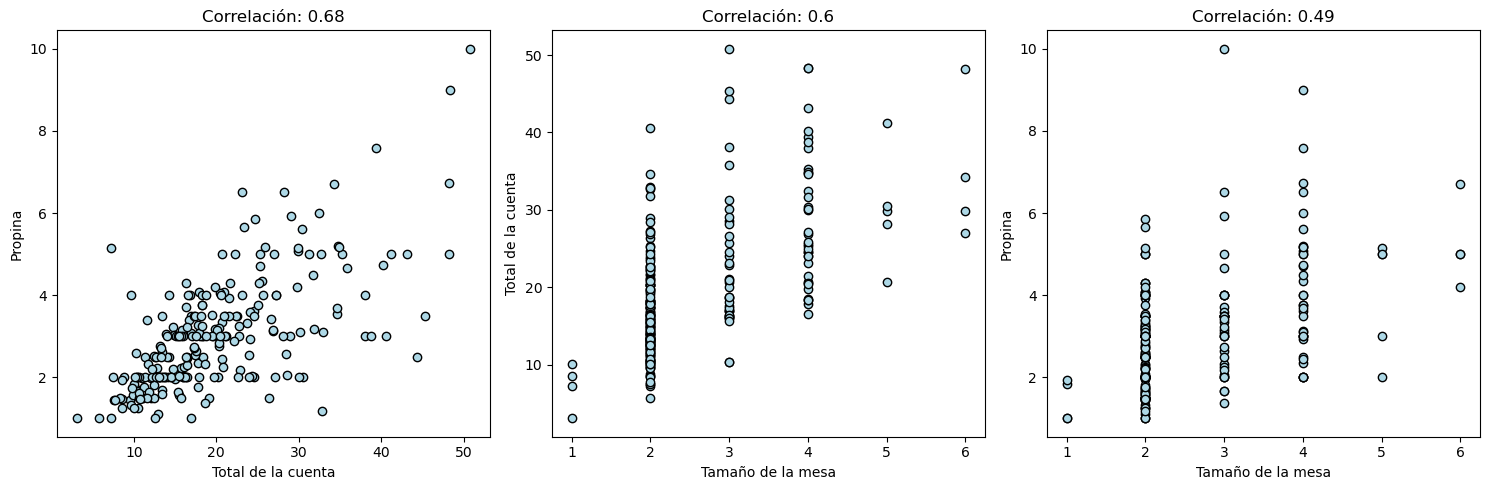

In [25]:
# Visualizar correlaciones
fig, ax = plt.subplots(1,3,figsize=(15, 5))
ax[0].scatter(df_tips['total_bill'], df_tips['tip'], color='lightblue', edgecolor='black')
ax[0].set_title(f'Correlación: {corr_cuenta_propina}')
ax[0].set_xlabel('Total de la cuenta')
ax[0].set_ylabel('Propina')
ax[1].scatter(df_tips['size'], df_tips['total_bill'], color='lightblue', edgecolor='black')
ax[1].set_title(f'Correlación: {corr_mesa_cuenta}')
ax[1].set_xlabel('Tamaño de la mesa')
ax[1].set_ylabel('Total de la cuenta')
ax[2].scatter(df_tips['size'], df_tips['tip'], color='lightblue', edgecolor='black')
ax[2].set_title(f'Correlación: {corr_mesa_propina}')
ax[2].set_xlabel('Tamaño de la mesa')
ax[2].set_ylabel('Propina')
plt.tight_layout()

## **CHALLENGE: ANÁLISIS DESCRIPTIVO DE DATOS**

Una vez visto el ***Hands - On: Introducción a la estadística descriptiva***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Dentro de la siguiente dinámica, **se realizará un análisis de estadística descriptiva** haciendo uso de **operaciones vectorizadas y visualización de datos** a través del **dataset taxis** proveniente de la librería de ***Seaborn***.

Donde los análisis a realizar son:

*   **Análisis univariable**
*   **Análisis bivariable**

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importa las librerías:** Carga las bibliotecas de Numpy, Pandas, Seaborn y Matplotlib.pyplot.










In [1]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**2. Importa el dataset de taxis:** Crea una variable denominada df_taxis donde se importe el dataset taxis.

In [2]:
# Import dataset
df_taxis = sns.load_dataset('taxis')
df_taxis.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


**3. Muestra los datos generales del dataset:**

   * Muestra las propiedades del dataset.
   * Muestra el resumen estadístico del dataset.

In [3]:
# Mostrar propiedades de la tabla
df_taxis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [4]:
# Mostrar resumen estadístico
df_taxis.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


**4. Realiza un análisis de univariable:**

   * Cálcula las medidas de tendencia central de la columna total.
   * Cálcula las medidas de dispersión de la columna total.
   * Visualiza los gráficos de las medidas obtenidas en un subplot de 3 columnas.

In [5]:
# Definir medidas de tendencia central
media = round(df_taxis['total'].mean(), 2)
mediana = round(df_taxis['total'].median(), 2)
moda = round(df_taxis['total'].mode()[0], 2)
print(f'Las medidas de tendencia central son: media = {media}, mediana = {mediana} y moda = {moda}.')

mtc = [media, mediana, moda]
nombres = ['Media', 'Mediana', 'Moda']
mtc_colors = ['blue', 'orange', 'green']
mtc_configuraciones = list(zip(mtc, nombres, mtc_colors))

Las medidas de tendencia central son: media = 18.52, mediana = 14.16 y moda = 9.3.


In [6]:
# Definir medidas de dispersión
std = np.std(df_taxis['total'])
percentil = np.percentile(df_taxis['total'], [25, 50, 75])
q_1 = round(percentil[0], 2)
q_2 = round(percentil[1], 2)
q_3 = round(percentil[2], 2)
iqr = round(q_3 - q_1, 2)
print(f'Desviación estandar: {round(std, 2)}')
print(f'Q1 = {q_1}, Q2 = {q_2}, Q3 = {q_3}, IQR = {iqr}')

Desviación estandar: 13.81
Q1 = 10.8, Q2 = 14.16, Q3 = 20.3, IQR = 9.5


In [7]:
# Definir variables
x = range(len(df_taxis['total']))
y = df_taxis['total']

std_datos = [media, media + std, media - std]
std_nombres = ['Media', 'Desviación estandar', None]
std_colores = ['blue', 'red', 'red']
std_configuraciones = list(zip(std_datos, std_nombres, std_colores))

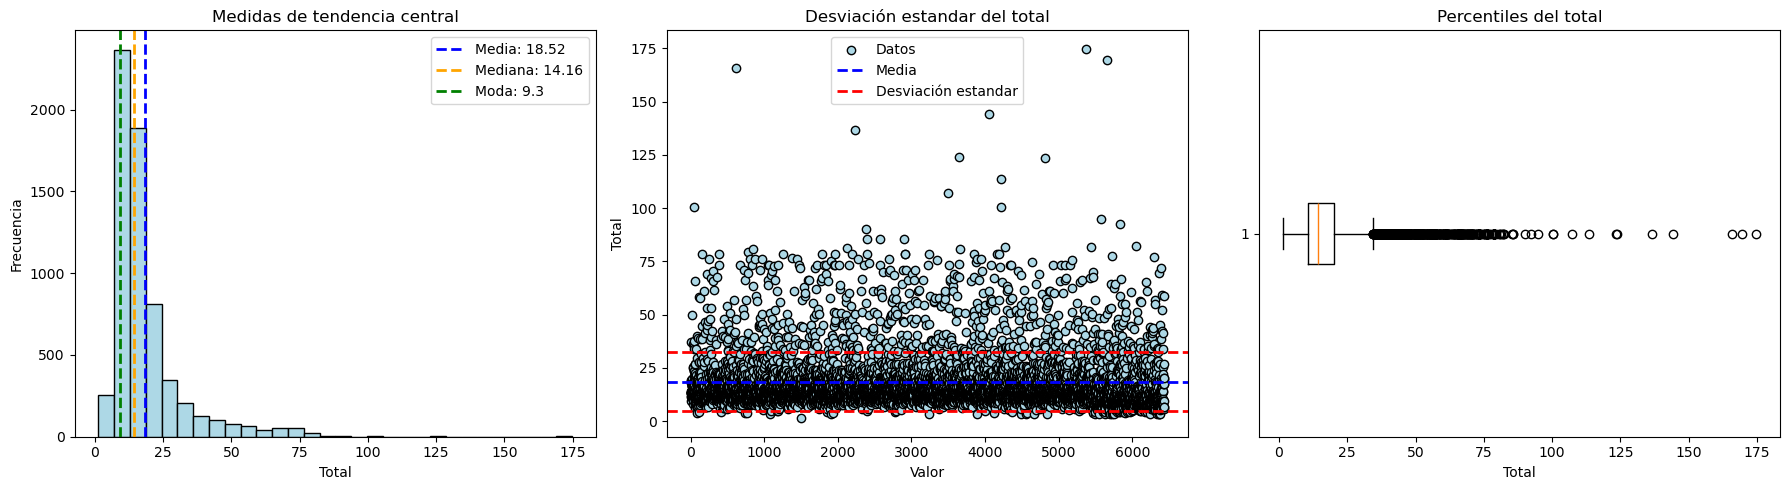

In [8]:
# Visualizar medidas descriptivas
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Histograma con medidas de tendencia central
ax[0].hist(df_taxis['total'], bins=30, color='lightblue', edgecolor='black')
ax[0].set_title('Medidas de tendencia central')
ax[0].set_xlabel('Total')
ax[0].set_ylabel('Frecuencia')
for dato, nombre, color in mtc_configuraciones:
    ax[0].axvline(x=dato, c=color, linestyle='--', linewidth=2, label=f'{nombre}: {dato}')
ax[0].legend()

# Dispersión con desviación estandar
ax[1].scatter(x, y, color='lightblue', edgecolor='black', label='Datos')
ax[1].set_title('Desviación estandar del total')
ax[1].set_xlabel('Valor')
ax[1].set_ylabel('Total')
for dato, nombre, color in std_configuraciones:
    ax[1].axhline(y=dato, c=color, label=nombre, linestyle='--', linewidth=2)
ax[1].legend()

# Boxplot con percentiles
ax[2].boxplot(df_taxis['total'], vert=False)
ax[2].set_title('Percentiles del total')
ax[2].set_xlabel('Total')

plt.tight_layout()
plt.show()

**5. Realiza un análisis de multivariable:** Visualiza en un mapa de calor los coeficientes de correlación para todos los pares posibles de las columnas numéricas del dataset.

In [9]:
# Definir variables
columnas = ['passengers', 'distance', 'fare', 'tip', 'tolls', 'total']
corr = df_taxis[columnas].corr()
long_col = len(columnas)
corr

,passengers,distance,fare,tip,tolls,total
passengers,1.000000,0.009411,0.007637,0.021099,-0.002903,0.015708
distance,0.009411,1.000000,0.920108,0.452589,0.635267,0.904676
fare,0.007637,0.920108,1.000000,0.488612,0.609307,0.974358
tip,0.021099,0.452589,0.488612,1.000000,0.413619,0.646186
tolls,-0.002903,0.635267,0.609307,0.413619,1.000000,0.683142
total,0.015708,0.904676,0.974358,0.646186,0.683142,1.000000


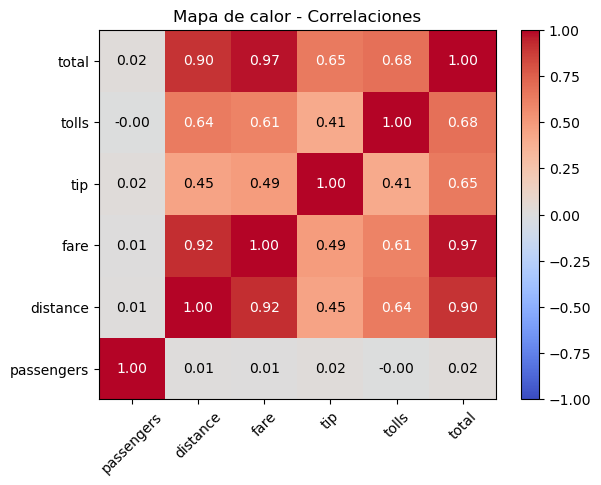

In [10]:
# Visualizar mapa de calor
heatmap = plt.pcolor(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de calor - Correlaciones')
plt.xticks(np.arange(0.5, long_col, 1), columnas, rotation=45)
plt.yticks(np.arange(0.5, long_col, 1), columnas)

for i in range(long_col):
    for j in range(long_col):
        plt.text(j + 0.5, i + 0.5, f'{corr.iloc[i, j]:.2f}',
                 ha='center', va='center',
                 color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black')
plt.colorbar(heatmap)
plt.show()

 **6. Realiza un análisis de bivariable:**

   * Cálcula los coeficientes de correlación de pearson de las 3 correlaciones mas fuertes obtenidas en el gráfico de calor.
   * Visualiza los gráficos de las correlaciones obtenidas en un subplot de 3 columnas.

In [11]:
# Definir variables
corr_dist_fare = round(df_taxis['distance'].corr(df_taxis['fare']), 2)
corr_dist_total = round(df_taxis['distance'].corr(df_taxis['total']), 2)
corr_fare_total = round(df_taxis['fare'].corr(df_taxis['total']), 2)
print(f'La correlación entre la distancia y la tarifa es: {corr_dist_fare}.')
print(f'La correlación entre la distancia y el total es: {corr_dist_total}.')
print(f'La correlación entre la tarifa y el total es: {corr_fare_total}.')

La correlación entre la distancia y la tarifa es: 0.92.
La correlación entre la distancia y el total es: 0.9.
La correlación entre la tarifa y el total es: 0.97.


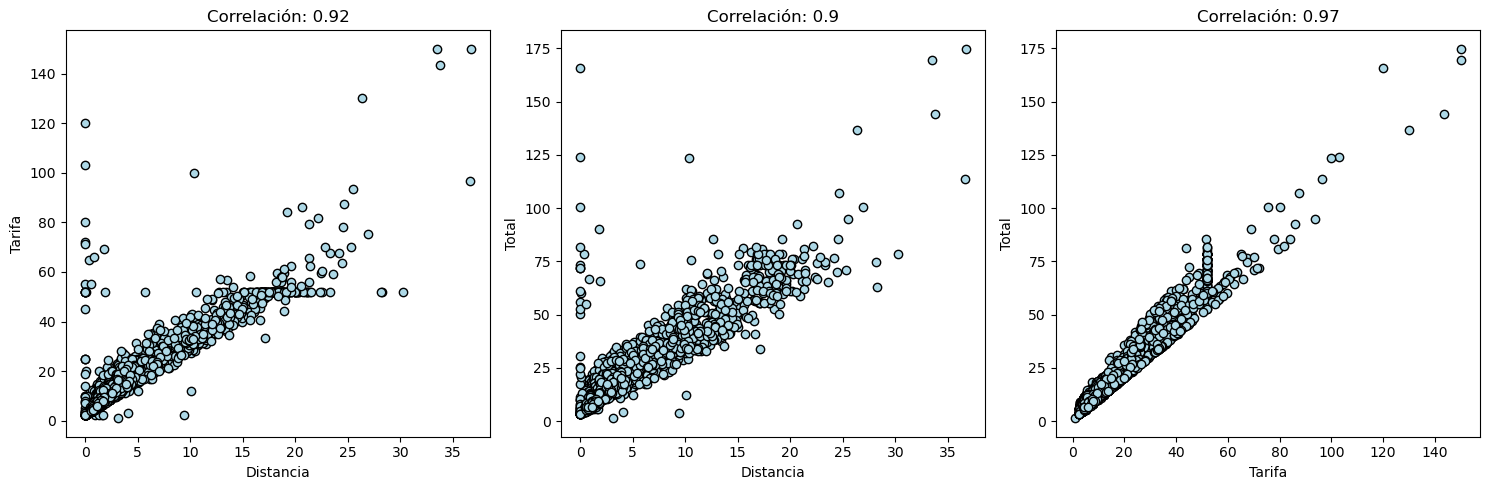

In [12]:
# Visualizar correlaciones
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].scatter(df_taxis['distance'], df_taxis['fare'], color='lightblue', edgecolor='black')
ax[0].set_title(f'Correlación: {corr_dist_fare}')
ax[0].set_xlabel('Distancia')
ax[0].set_ylabel('Tarifa')

ax[1].scatter(df_taxis['distance'], df_taxis['total'], color='lightblue', edgecolor='black')
ax[1].set_title(f'Correlación: {corr_dist_total}')
ax[1].set_xlabel('Distancia')
ax[1].set_ylabel('Total')

ax[2].scatter(df_taxis['fare'], df_taxis['total'], color='lightblue', edgecolor='black')
ax[2].set_title(f'Correlación: {corr_fare_total}')
ax[2].set_xlabel('Tarifa')
ax[2].set_ylabel('Total')

plt.tight_layout()
plt.show()